In [1]:
# Set up
import pandas as pd
import numpy as np
from scipy import stats
import datetime
import os
import sys
import gc
# import seaborn as sns
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import hex2color, rgb2hex
import matplotlib as mpl

# For I/O
script_path = os.getcwd()


def create_colormap(colors, n):
    """
    Create a continuous colormap from a list of hex colors.
    
    Parameters:
        colors (list): List of hex color strings (e.g., ['#FFFF00', '#0000FF'])
        n (int): Number of colors to output
        
    Returns:
        list: List of n hex colors interpolated between input colors
    """
    # Convert hex colors to RGB
    rgb_colors = [hex2color(color) for color in colors]
    
    # Create position array for input colors
    positions = np.linspace(0, 1, len(colors))
    
    # Create position array for output colors
    output_positions = np.linspace(0, 1, n)
    
    # Initialize output RGB arrays
    r = np.interp(output_positions, positions, [color[0] for color in rgb_colors])
    g = np.interp(output_positions, positions, [color[1] for color in rgb_colors])
    b = np.interp(output_positions, positions, [color[2] for color in rgb_colors])
    
    # Convert back to hex
    output_colors = [rgb2hex((r[i], g[i], b[i])) for i in range(n)]
    
    return output_colors

def get_fuel_labels(fuel):
    fuel_labels = {
        'car_diesel' : 'Diesel', 
        'car_petrol' : 'Petrol', 
        'car_hev' : 'HEV', 
        'car_bev' : 'BEV',
        'lgv': 'LGV',
        'mcycle' : 'Motorcycle',
        'car_bev_battery_30' : "< 30 kWh",
        'car_bev_battery_60' : "30-60 kWh",
        'car_bev_battery_100' : "> 60 kWh",
        'car_bev_make_TESLA' : "Tesla",
        'car_bev_make_NISSAN' : "Nissan",
        'car_bev_make_RENAULT' : "Renault",
        'car_bev_make_BMW' : "BMW",
        'car_bev_make_KIA' : "Kia",
        'car_bev_make_HYUNDAI' : "Hyundai",
        }
    return  fuel_labels[fuel]

def get_fuel_labels_disag(fuel):
    fuel_labels = {
        'car_diesel' : 'Diesel', 
        'car_petrol' : 'Petrol', 
        'car_hev' : 'HEV', 
        'car_bev' : 'All BEVs',
        'lgv': 'LGV',
        'mcycle' : 'Motorcycle',
        'car_bev_battery_30' : "< 30 kWh",
        'car_bev_battery_60' : "30-60 kWh",
        'car_bev_battery_100' : "> 60 kWh",
        'car_bev_make_TESLA' : "Tesla",
        'car_bev_make_NISSAN' : "Nissan",
        'car_bev_make_RENAULT' : "Renault",
        'car_bev_make_BMW' : "BMW",
        'car_bev_make_KIA' : "Kia",
        'car_bev_make_HYUNDAI' : "Hyundai",
        }
    return  fuel_labels[fuel]

def get_fuel_cut_off_year(fuel):
    fuel_cut_off_year = {
        'car_diesel' : 1994, 
        'car_petrol' : 1994, 
        'car_hev' : 2007, 
        'car_bev' : 2012,
        'lgv': 1994,
        'mcycle' : 1994
        }
    return fuel_cut_off_year[fuel]

def y_fmt(y, pos):
    decades = [1e9, 1e6, 1e3, 1e0, 1e-3, 1e-6, 1e-9 ]
    suffix  = ["G", "M", "k", "" , "m" , "u", "n"  ]
    if y == 0:
        return str(0)
    for i, d in enumerate(decades):
        if np.abs(y) >=d:
            val = y/float(d)
            signf = len(str(val).split(".")[1])
            if signf == 0:
                return '{val:d} {suffix}'.format(val=int(val), suffix=suffix[i])
            else:
                if signf == 1:
                    #print val, signf
                    if str(val).split(".")[1] == "0":
                       return '{val:d} {suffix}'.format(val=int(round(val)), suffix=suffix[i]) 
                tx = "{"+"val:.{signf}f".format(signf = signf) +"} {suffix}"
                return tx.format(val=val, suffix=suffix[i])


plt.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"], 
    "font.size": 5,               
    "axes.titlesize": 5,
    "axes.labelsize": 5,
    "xtick.labelsize": 5,
    "ytick.labelsize": 5,
    "legend.fontsize": 5,
    "figure.titlesize": 5,

    "axes.linewidth": 0.5,
    "lines.linewidth": 0.75,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    
    # PDF/EPS font embedding 
    "pdf.fonttype": 42,            
    "ps.fonttype": 42,
})

In [2]:
# Prepare the data for Figure 6

fuel_filename_lookup = {
    'car_diesel' : "sample_car_diesel_all_years.parquet",
    'car_petrol' : "sample_car_petrol_all_years.parquet",
    'car_hev' : "sample_car_hev_all_years.parquet",
    'car_bev' : "sample_car_bev_all_years.parquet",
    }

df_fuel_historical = {}

# read in a format the electrcity gen data:
fname = "electricity_data_2009_2050.csv"
fpath = os.path.join(script_path, "data", "electricity_data", fname)
df_electricity_data = pd.read_csv(fpath)
df_electricity_data['AEF'] = df_electricity_data['gco2_kwh']
df_electricity_data['test_year'] = df_electricity_data['Year']

for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    
    filename = fuel_filename_lookup[fuel]
    folder = "sample_data"
    fpath = os.path.join(script_path, "data",  folder, filename)
    df = pd.read_parquet(fpath, engine='pyarrow', columns=["test_year", "vehicle_id", "age_year_rounded", "mileage_between_tests", "battery capacity (kWh)", "mass (kg)", "fuel efficiency Wh/mi", "CO2 g/km", "first_use_year", "last_test", "test_mileage", "age_year"])
    
    print(f"Processing Historical Data {fuel}")
    
    if fuel == "car_bev":
        
        df = df.merge(df_electricity_data, left_on=["test_year"],  right_on=["test_year"], how="left")

        # drop any vehicles without battery, weight or, fuel efficiency data - already performed, but keep for clarity
        df = df.dropna(subset=["battery capacity (kWh)", "mass (kg)", "fuel efficiency Wh/mi"])
        # Calculate the total electricity consumed for each row
        df["T&D Losses"] = 1/0.925 # 7.5% Loss
        df["Charging Losses"] = 1/0.90 # 10% Loss
        df["Electricity Consumed (kWh) between tests"] = (df["fuel efficiency Wh/mi"] * df["mileage_between_tests"] * df["T&D Losses"] * df["Charging Losses"])/1000
        # Now calculate the emissions
        df["Emissions (AEF g) between tests"] = df["Electricity Consumed (kWh) between tests"] * df["AEF"]
        # Convert to tones
        df["Emissions (AEF t) between tests"] = df["Emissions (AEF g) between tests"] / 1_000_000
        # Now get cumulative emissions for each vehicle_id using shift
        df["Cumulative Emissions (AEF t)"] = df.groupby("vehicle_id")["Emissions (AEF t) between tests"].cumsum()
        df["battery mass (kg)"] = 7 * df["battery capacity (kWh)"]
        df["mass non-battery (kg)"] = df["mass (kg)"] - df["battery mass (kg)"]
        # Now for manufacturing emissions
        df["Chasis (t)"] = df["mass non-battery (kg)"] * 0.0047 # 4.7 CO2 kg per kg from Bieker 2021
        df["Battery (t)"] = df["battery capacity (kWh)"] * 0.078 # 78 CO2 kg per kWh from Hill et al (2020)
        df["Manufacturing Emissions (t)"] = df["Chasis (t)"] + df["Battery (t)"]
        df["Cumulative LCA CO2 (t)"] = df["Cumulative Emissions (AEF t)"] + df["Manufacturing Emissions (t)"]
        
    else:
        
        # drop any vehicles without fuel efficiency data or mass - already performed in data processing, but keep for clarity
        df = df.dropna(subset=["CO2 g/km", "mass (kg)"])
        
        # Calculate the TTW emissions
        df["TTW CO2 (t)"]  = 0.0
        df.loc[df["age_year_rounded"] == 0, "TTW CO2 (t)"] = 0
        df.loc[df["age_year_rounded"] != 0, "TTW CO2 (t)"] = (df["mileage_between_tests"] * df["CO2 g/km"] * 1.61) / 1_000_000 # need to convert to km (1.61) and grams to tonnes
        df["WTT CO2 (t)"] = df["TTW CO2 (t)"] * 0.11 # or 90.4% efficient from GREET ANL 2019
        df["WTW CO2 (t)"] = df["TTW CO2 (t)"] + df["WTT CO2 (t)"]
        # Now get cumulative emissions for each vehicle_id using shift
        df["Cumulative WTW CO2 (t)"] = df.groupby("vehicle_id")["WTW CO2 (t)"].cumsum()
        # Now for manufacturing emissions
        df["Chasis (t)"] = df["mass (kg)"] * 0.0052 # 5.2 CO2 tonnes per kg from Bieker 2021
        df["Manufacturing Emissions (t)"] = df["Chasis (t)"]
        # Now add the manufacturing emissions to the cumulative emissions - LCA Emissions
        df["Cumulative LCA CO2 (t)"] = df["Cumulative WTW CO2 (t)"] + df["Manufacturing Emissions (t)"]

    df_fuel_historical[fuel] = df
    filename = f"sample_{fuel}_all_years_with_cumulative_emissions.parquet"
    fpath = os.path.join(script_path, "data", "sample_data", filename)
    df.to_parquet(fpath, engine='pyarrow', compression='snappy')

# Projection data     

fuel_filename_lookup = {
    'car_diesel' : "simulation_car_diesel.parquet",
    'car_petrol' : "simulation_car_petrol.parquet",
    'car_hev' : "simulation_car_hev.parquet",
    'car_bev' : "simulation_car_bev.parquet",
    }

fuel_lookup = {
    'car_diesel' : "DI",
    'car_petrol' : "PE",
    'car_hev' : "HY",
    'car_bev' : "EL",
}
df_fuel_simulated = {}
fname = "simulation_data_revision"
fpath = os.path.join(script_path, "data", "simulation_data", f"{fname}.csv")
df = pd.read_csv(fpath, engine='pyarrow', usecols=["test_year", "vehicle_id", "mileage_per_year", "time_between_tests", "simulated_data", "original_fuel_type", "battery capacity (kWh)", "mass (kg)", "fuel efficiency Wh/mi", "CO2 g/km", "first_use_year", "last_test", "test_mileage", "age_year"])
df["age_year_rounded"] = df["age_year"].round(0).astype(int)
df.loc[df["simulated_data"] == False, "mileage_between_tests"] = df["mileage_per_year"] * df["time_between_tests"]
df.loc[df["simulated_data"] == True, "mileage_between_tests"] = df["mileage_per_year"]
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    df_fuel_simulated[fuel] = df[df["original_fuel_type"] == fuel_lookup[fuel]]
    
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:

    df = df_fuel_simulated[fuel]
    
    print(f"Processing Simulated Data {fuel}")
    
    if fuel == "car_bev":
        
        df = df.merge(df_electricity_data, left_on=["test_year"],  right_on=["test_year"], how="left")
        
        # drop any vehicles without battery, weight or, fuel efficiency data - already performed in data processing, but keep for clarity
        df = df.dropna(subset=["battery capacity (kWh)", "mass (kg)", "fuel efficiency Wh/mi"])
        
        # Calculate the total electricity consumed for each row
        df["T&D Losses"] = 1/0.925 # 7.5% Loss
        df["Charging Losses"] = 1/0.90 # 10% Loss
        df["Electricity Consumed (kWh) between tests"] = (df["fuel efficiency Wh/mi"] * df["mileage_between_tests"] * df["T&D Losses"] * df["Charging Losses"])/1000
        # Now calculate the emissions
        df["Emissions (AEF g) between tests"] = df["Electricity Consumed (kWh) between tests"] * df["AEF"]
        # Convert to tones
        df["Emissions (AEF t) between tests"] = df["Emissions (AEF g) between tests"] / 1_000_000
        # Now get cumulative emissions for each vehicle_id using shift
        df["Cumulative Emissions (AEF t)"] = df.groupby("vehicle_id")["Emissions (AEF t) between tests"].cumsum()
    
        df["battery mass (kg)"] = 7 * df["battery capacity (kWh)"]
        df["mass non-battery (kg)"] = df["mass (kg)"] - df["battery mass (kg)"]
        # Now for manufacturing emissions
        df["Chasis (t)"] = df["mass non-battery (kg)"] * 0.0047 # 4.7 CO2 kg per kg from Bieker 2021
        df["Battery (t)"] = df["battery capacity (kWh)"] * 0.078 # 78 CO2 kg per kWh from Hill et al (2020)
        df["Manufacturing Emissions (t)"] = df["Chasis (t)"] + df["Battery (t)"]
        df["Cumulative LCA CO2 (t)"] = df["Cumulative Emissions (AEF t)"] + df["Manufacturing Emissions (t)"]
        
    else:
        
        # drop any vehicles without fuel efficiency data or mass- already performed in data processing, but keep for clarity
        df = df.dropna(subset=["CO2 g/km", "mass (kg)"])
        
        # Calculate the TTW emissions
        df["TTW CO2 (t)"]  = 0.0
        df.loc[df["age_year_rounded"] == 0, "TTW CO2 (t)"] = 0
        df.loc[df["age_year_rounded"] != 0, "TTW CO2 (t)"] = (df["mileage_between_tests"] * df["CO2 g/km"] * 1.61) / 1_000_000 # need to convert to km (1.61) and grams to tonnes
        df["WTT CO2 (t)"] = df["TTW CO2 (t)"] * 0.11 # or 90.4% efficient from GREET ANL 2019
        df["WTW CO2 (t)"] = df["TTW CO2 (t)"] + df["WTT CO2 (t)"]
        # Now get cumulative emissions for each vehicle_id using shift
        df["Cumulative WTW CO2 (t)"] = df.groupby("vehicle_id")["WTW CO2 (t)"].cumsum()
        # Now for manufacturing emissions
        df["Chasis (t)"] = df["mass (kg)"] * 0.0052 # 5.2 CO2 kg per kg from Bieker 2021
        df["Manufacturing Emissions (t)"] = df["Chasis (t)"]
        # Now add the manufacturing emissions to the cumulative emissions - LCA Emissions
        df["Cumulative LCA CO2 (t)"] = df["Cumulative WTW CO2 (t)"] + df["Manufacturing Emissions (t)"]

    df_fuel_simulated[fuel] = df
    folder = "simulation_data"
    filename = f"simulation_{fuel}_with_cumulative_emissions.parquet"
    fpath = os.path.join(script_path, "data", folder, filename)
    df.to_parquet(fpath, engine='pyarrow', compression='snappy')            

Processing Historical Data car_hev
Processing Historical Data car_bev
Processing Historical Data car_diesel
Processing Historical Data car_petrol
Processing Simulated Data car_hev
Processing Simulated Data car_bev
Processing Simulated Data car_diesel
Processing Simulated Data car_petrol


Plot a
Plot b
Plot d upper
Plot d lower
Plot c upper
car_hev
car_bev
car_diesel
car_petrol
Plot c lower


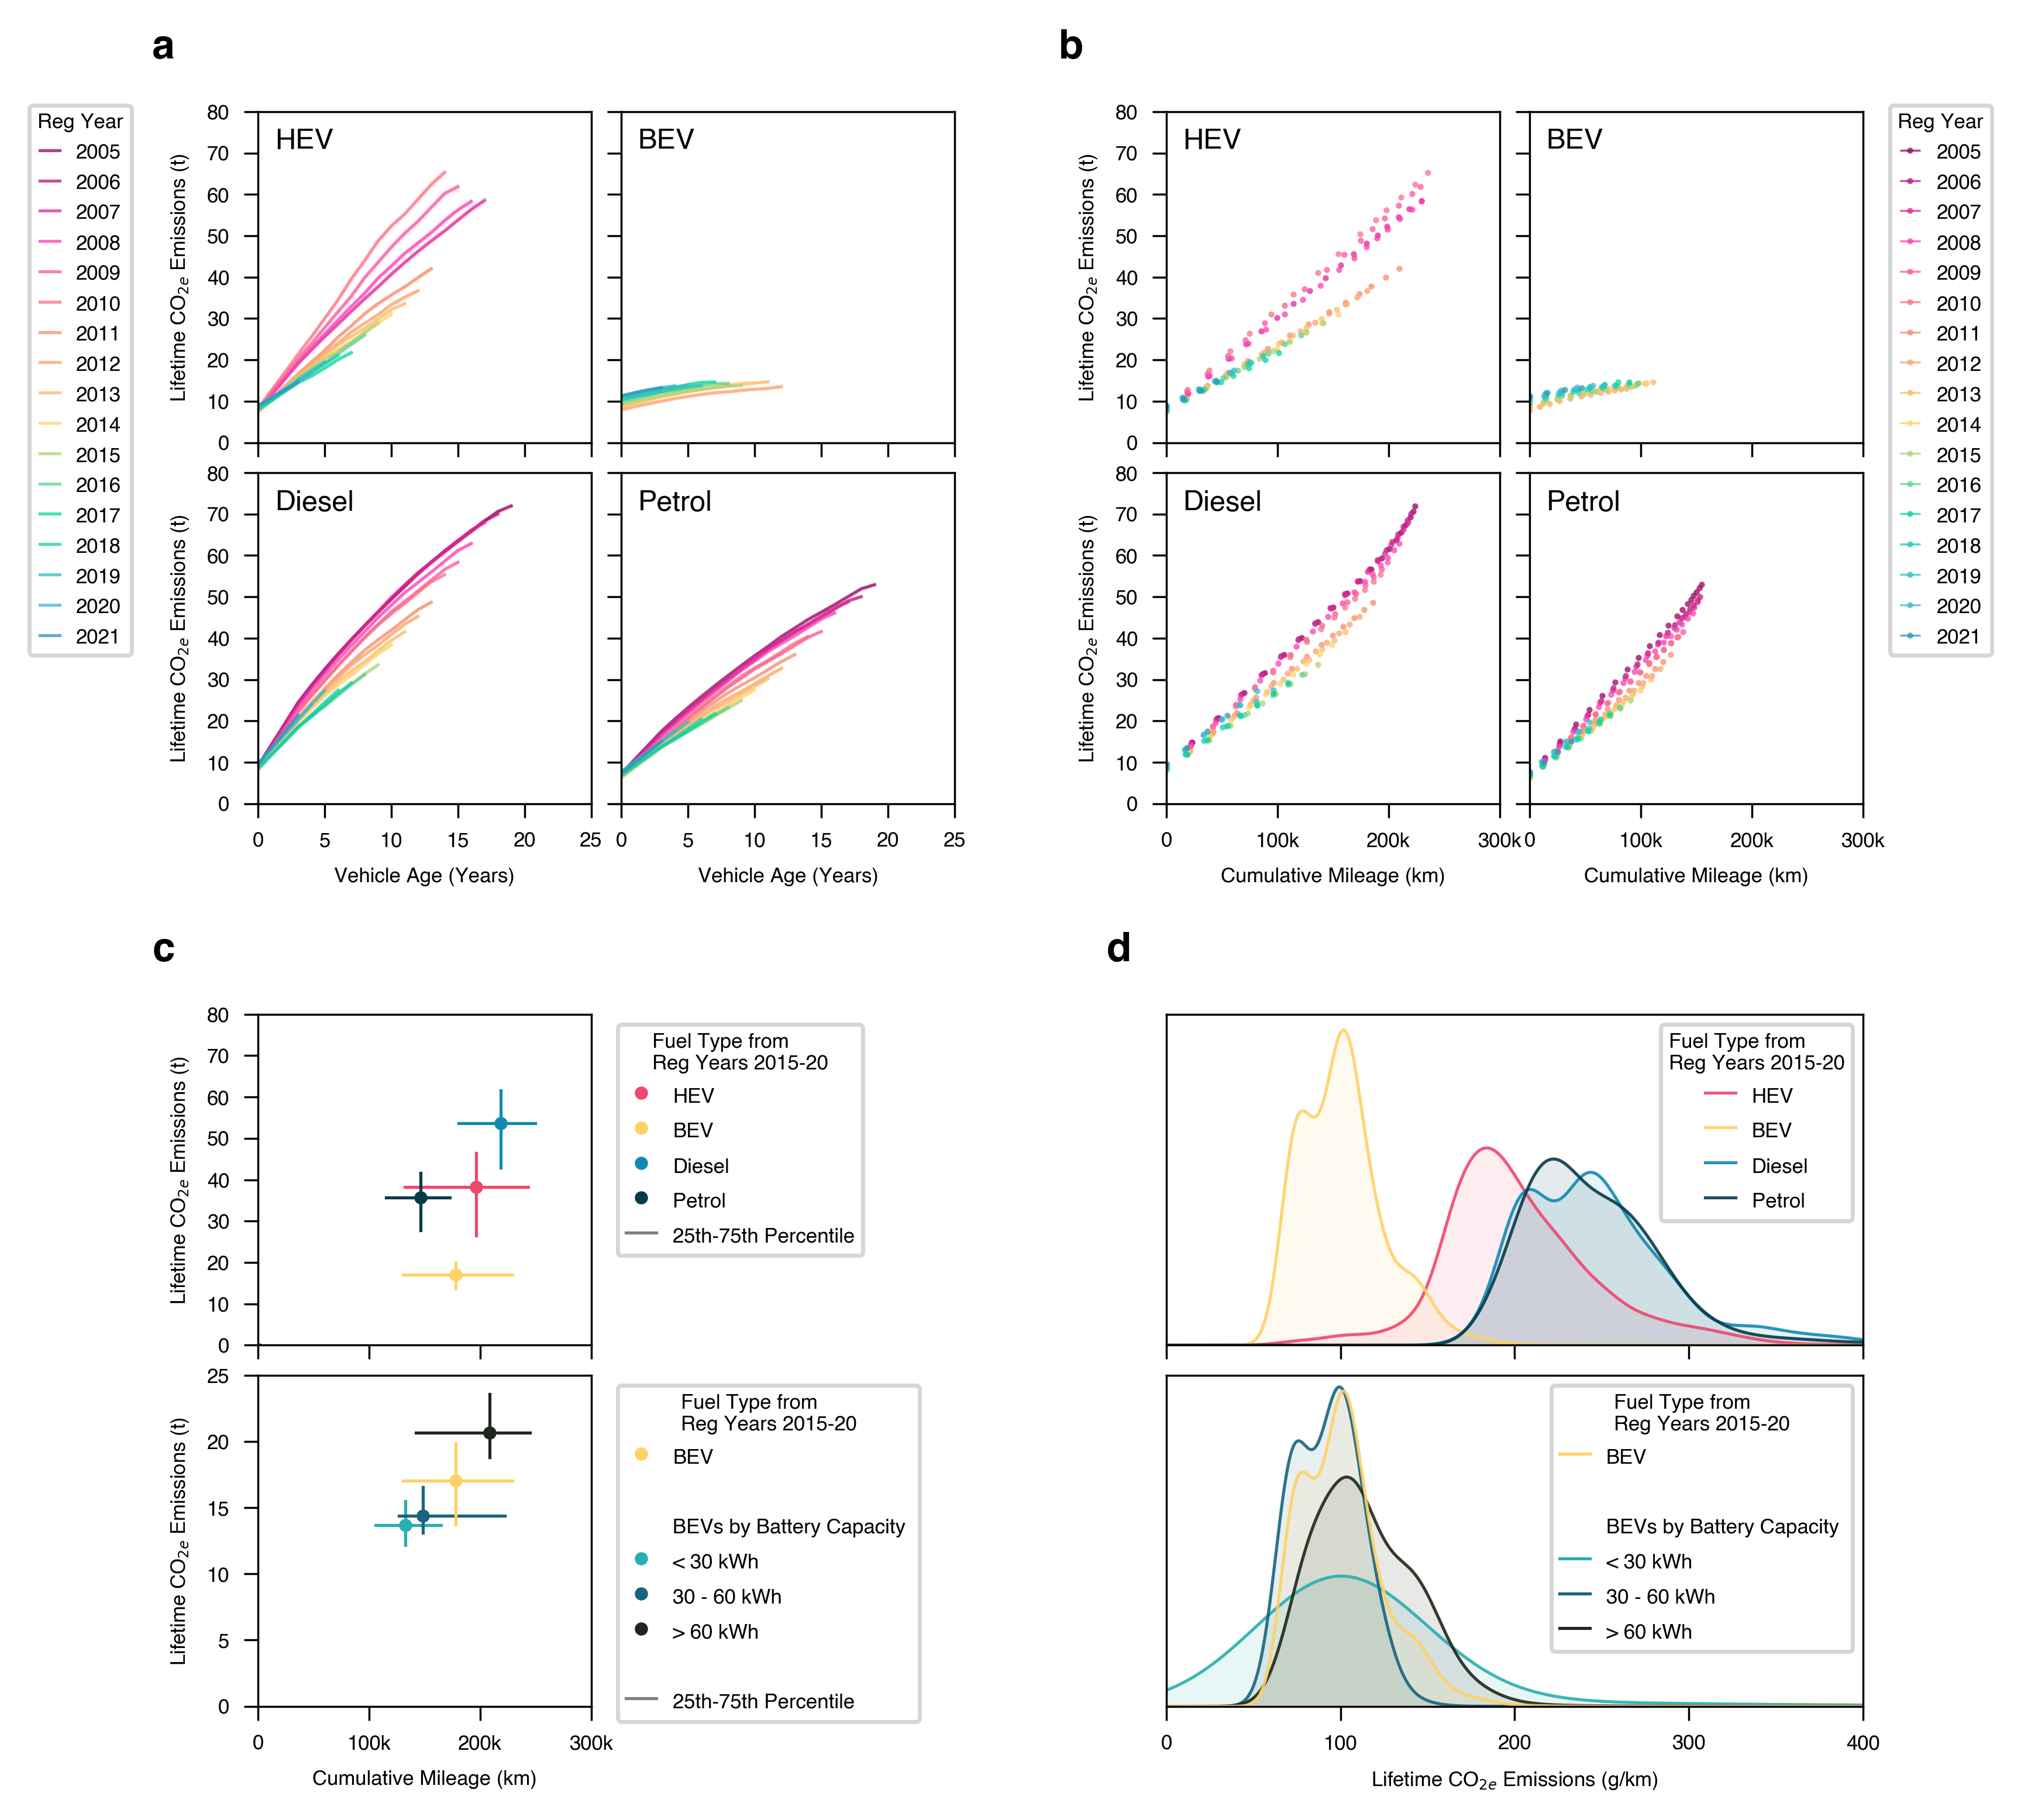

In [3]:
# Figure 6

# Colours, fuels, and MOT years to iterate over and use for plotting
full_years = list(range(2005, 2024, 1))
# base_colors = ["#38030F", "#EF476F", "#F78C6B", "#FFD166", "#06D6A0", "#48B3D7", "#0A7EA5", "#093E50", "#001B24"]
base_colors = ["#9A015F","#FD3DB5", "#F78C6B", "#FFD166", "#06D6A0", "#48B3D7", "#005672"]
n = len(full_years)
colors = create_colormap(base_colors, n)
all_colors_lookup = {year : color for year, color in zip(full_years, colors)}

fig = plt.figure(figsize=(7.08, 7.08), dpi=500)
gs = fig.add_gridspec(9, 9)

# First Row - Annual Mileage
# Fig A
ax1_a = fig.add_subplot(gs[0:2, 0:2])
ax2_a = fig.add_subplot(gs[0:2, 2:4])
ax3_a = fig.add_subplot(gs[2:4, 0:2])
ax4_a = fig.add_subplot(gs[2:4, 2:4])
a_axes = [ax1_a, ax2_a, ax3_a, ax4_a]

# Fig B
ax1_b = fig.add_subplot(gs[0:2, 5:7])
ax2_b = fig.add_subplot(gs[0:2, 7:9])
ax3_b = fig.add_subplot(gs[2:4, 5:7])
ax4_b = fig.add_subplot(gs[2:4, 7:9])
b_axes = [ax1_b, ax2_b, ax3_b, ax4_b]

# Fig C
ax_d_upper = fig.add_subplot(gs[5:7, 5:9])

# Fig D
ax_d_lower = fig.add_subplot(gs[7:9, 5:9]) 

# Fig E
ax_c_upper = fig.add_subplot(gs[5:7, 0:2]) 

# Fig F
ax_c_lower = fig.add_subplot(gs[7:9, 0:2]) 


fuels = ["car_hev", "car_bev", "car_diesel", "car_petrol"]
fuel_colours = ["#ef476f", "#ffd166","#118ab2", "#073b4c"]
fuel_colors_lookup = {fuel : color for fuel, color in zip(fuels, fuel_colours)}
bev_values = {}

data_out = []
print("Plot a")
for fuel, ax in zip(["car_hev", "car_bev", "car_diesel", "car_petrol"], a_axes):
    
    df = df_fuel_historical[fuel]
    # Remove any vehicles that are no longer in use
    ids = df.loc[(df["last_test"] == True)&(df["test_year"] < 2023) ,"vehicle_id"].unique()
    df_view = df[~df["vehicle_id"].isin(ids)]
    
    for reg_year in range(2005, 2022, 1):
        
        color = all_colors_lookup[reg_year]
        last_mot_year = 2024
        max_age = 2024 - reg_year
        fuel_cut_off_year = get_fuel_cut_off_year(fuel)
        
        if reg_year < fuel_cut_off_year:
            # Add fake line to data to fill in the legend
            ax.plot([-5], [-5], label=str(reg_year), color=color, linewidth=0.75, alpha=0.75)
            continue
        
        ages = []
        emissions = []
        std_errors = []
        n = []
        for age in range(0, max_age+1, 1):
            # Filter the data
            df_age = df_view[(df_view["first_use_year"] == reg_year) & (df_view["age_year_rounded"] == age)]
            # drop duplicates of vehicle_id - keep the last record
            df_age = df_age.drop_duplicates(subset=["vehicle_id"], keep='last')
            ages.append(age)
            emissions.append(df_age["Cumulative LCA CO2 (t)"].mean())
            std_errors.append(df_age["Cumulative LCA CO2 (t)"].std() / np.sqrt(len(df_age)))
            n.append(len(df_age))
        
        ax.plot(ages, emissions, label=str(reg_year), color=color, linewidth=0.75, alpha=0.75)
        
        y_upper = [em + se for em, se in zip(emissions, std_errors)]
        y_lower = [em - se for em, se in zip(emissions, std_errors)]
        ax.fill_between(ages, y_lower, y_upper, color=color, alpha=0.1)
        
        for i in range(len(ages)):
            data_out.append([fuel, reg_year, ages[i], emissions[i], std_errors[i], n[i]])
    
    # Format the axis
    ax.set_ylim(0, 80)    
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Lifetime CO$_{2e}$ Emissions (t)")
    else:
        ax.set_yticklabels([])
    ax.set_xlim(0,25)   
    ax.set_xticks([0, 5, 10, 15, 20, 25])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Vehicle Age (Years)")
    else:
        ax.set_xticklabels([])   
    ax.text(0.05, 0.95, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='left')
    
ax1_a.legend(
    title="Reg Year",
    title_fontsize=5,   
    loc='upper right', 
    fontsize=5, 
    handlelength=1, 
    handleheight=1,
    bbox_to_anchor=(-0.35, 1.05)
)  
        
data_out = pd.DataFrame(data_out, columns=["fuel", "reg_year", "age", "emissions", "std_error", "n"])
data_out.to_csv(os.path.join(script_path, "results", "figure_6_plot_a.csv"), index=False)

data_out = []
print("Plot b")
for fuel, ax in zip(["car_hev", "car_bev", "car_diesel", "car_petrol"], b_axes):
    
    df = df_fuel_historical[fuel]
    # Remove any vehicles that are no longer in use
    ids = df.loc[(df["last_test"] == True)&(df["test_year"] < 2023) ,"vehicle_id"].unique()
    df_view = df[~df["vehicle_id"].isin(ids)]
    
    for reg_year in range(2005, 2022, 1):
        color = all_colors_lookup[reg_year]
        last_mot_year = 2024
        max_age = 2024 - reg_year
        fuel_cut_off_year = get_fuel_cut_off_year(fuel)
        if reg_year < fuel_cut_off_year:
            # Add fake line to data to fill in the legend
            ax.errorbar([-5], [-5], xerr=[1], color=color, alpha=0.75, linewidth=0.5, marker = 'o', markersize=1.5, linestyle='none', markeredgecolor='none', label=str(reg_year))
            continue
        
        ages = []
        emissions = []
        std_errors = []
        n = []
        mileage = []
        for age in range(0, max_age+1, 1):
            # Filter the data
            df_view = df[(df["first_use_year"] == reg_year) & (df["age_year_rounded"] == age)]
            # drop duplicates of vehicle_id - keep the last record
            df_view = df_view.drop_duplicates(subset=["vehicle_id"], keep='last')
            ages.append(age)
            emissions.append(df_view["Cumulative LCA CO2 (t)"].mean())
            std_errors.append(df_view["Cumulative LCA CO2 (t)"].std() / np.sqrt(len(df_view)))
            n.append(len(df_view))
            mileage.append(df_view["test_mileage"].mean()*1.61) # Convert to km
            
        ax.errorbar(mileage, emissions, xerr=std_errors, color=color, alpha=0.75, linewidth=0.5, marker = 'o', markersize=1.5, linestyle='none', markeredgecolor='none', label=str(reg_year))
        
        for i in range(len(ages)):
            data_out.append([fuel, reg_year, ages[i], emissions[i], std_errors[i], n[i], mileage[i]])
    
    # Format the axis
    ax.set_ylim(0, 80)    
    if fuel in ["car_diesel", "car_hev"]:
        ax.set_ylabel("Lifetime CO$_{2e}$ Emissions (t)")
    else:
        ax.set_yticklabels([])
    ax.set_xlim(0, 300_000)    
    ax.set_xticks([0, 100_000, 200_000, 300_000])
    ax.set_xticklabels(["0", "100k", "200k", "300k"])
    if fuel in ["car_petrol", "car_diesel"]:
        ax.set_xlabel("Cumulative Mileage (km)")
    else:
        ax.set_xticklabels([])   
    ax.text(0.05, 0.95, f"{get_fuel_labels(fuel)}", transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='left')
    
ax2_b.legend(
    title="Reg Year",
    title_fontsize=5,   
    loc='upper left', 
    fontsize=5,
    handlelength=1, 
    handleheight=1,
    bbox_to_anchor=(1.05, 1.05)
)  
 
data_out = pd.DataFrame(data_out, columns=["fuel", "reg_year", "age", "emissions", "std_error", "n", "mileage"])
data_out.to_csv(os.path.join(script_path, "results", "figure_6_plot_b.csv"), index=False)          

data_out_d = []
ax = ax_d_upper
print("Plot d upper")
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    
    color = fuel_colors_lookup[fuel]
    df = df_fuel_simulated[fuel]    
    df_view = df[(df['last_test'] == True) & ((df["simulated_data"]==True))]
    lca_co2_per_km = df_view["Cumulative LCA CO2 (t)"] / (df_view["test_mileage"]*1.61) 
    # convert tons to grams
    lca_co2_per_km = lca_co2_per_km * 1_000_000
    
    # estimate kde and plot
    kde_default = stats.gaussian_kde(lca_co2_per_km, bw_method='scott')
    kde = stats.gaussian_kde(lca_co2_per_km, bw_method=kde_default.factor * 3)
    x = np.linspace(0, 400, 1000)
    y = kde(x)
    ax.plot(x, y, color=color, alpha=0.9, label=f"{get_fuel_labels(fuel)}")
    y_lower = [0] * len(x)
    ax.fill_between(x, y_lower, y, color=color, alpha=0.1, edgecolor=None)
    for xi, yi in zip(x.tolist(), y.tolist()):
        data_out_d.append([fuel, None, float(xi), float(yi)])

ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlim(0, 400)
ax.set_xticklabels([])
ax.set_ylim(bottom=0)
ax.set_yticks([])

# get ylims for next ax
y_lim_lower = ax.get_ylim()[0]
y_lim_upper = ax.get_ylim()[1]

ax.legend(title="Fuel Type from\nReg Years 2015-20",  
          loc='upper right', 
          ncols=1, 
          handlelength=1.5, 
          handleheight=1.5,
          fontsize=5
)

battery_colors_lookup = {
    30 : "#28AFB0",
    60 : "#19647E",
    100 : "#1F271B"
}

ax = ax_d_lower
print("Plot d lower") 
for fuel in ["car_bev"]:

    df = df_fuel_simulated[fuel]    
    df_view = df[(df['last_test'] == True) & ((df["simulated_data"]==True))]

    for battery_size_id, battery_range in zip([30, 60, 100], [[0, 30], [30, 60], [60, 200]]):
   
        color = battery_colors_lookup[battery_size_id]
        df_view = df[(df['last_test'] == True) & (df["battery capacity (kWh)"] > battery_range[0]) & (df["battery capacity (kWh)"] <= battery_range[1])]
        lca_co2_per_km = df_view["Cumulative LCA CO2 (t)"] / (df_view["test_mileage"]*1.61) 
        # convert tons to grams
        lca_co2_per_km = lca_co2_per_km * 1_000_000
        # estimate kde and plot
        kde_default = stats.gaussian_kde(lca_co2_per_km, bw_method='scott')
        kde = stats.gaussian_kde(lca_co2_per_km, bw_method=kde_default.factor * 3)
        x = np.linspace(0, 400, 1000)
        y = kde(x)
        ax.plot(x, y, color=color, alpha=0.9)   
        y_lower = [0] * len(x)
        ax.fill_between(x, y_lower, y, color=color, alpha=0.1, edgecolor=None)
        for xi, yi in zip(x.tolist(), y.tolist()):
            data_out_d.append([f"car_bev_battery_{battery_size_id}", battery_size_id, float(xi), float(yi)])
        
    df_view = df[(df['last_test'] == True) & ((df["simulated_data"]==True))]
    
    color = fuel_colors_lookup[fuel]
    lca_co2_per_km = df_view["Cumulative LCA CO2 (t)"] / (df_view["test_mileage"]*1.61) 
    # convert tons to grams
    lca_co2_per_km = lca_co2_per_km * 1_000_000
    # estimate kde and plot
    kde_default = stats.gaussian_kde(lca_co2_per_km, bw_method='scott')
    kde = stats.gaussian_kde(lca_co2_per_km, bw_method=kde_default.factor * 3)
    x = np.linspace(0, 400, 1000)
    y = kde(x)
    ax.plot(x, y, color=color, alpha=0.9)
    y_lower = [0] * len(x)
    ax.fill_between(x, y_lower, y, color=color, alpha=0.1, edgecolor=None)
    for xi, yi in zip(x.tolist(), y.tolist()):
        data_out_d.append(["car_bev", None, float(xi), float(yi)])
    
# Add lines for legend
# ax.plot([-1], [-1], color='white', linewidth=1, label="Vehicles by Fuel Type")  
color = fuel_colors_lookup["car_bev"]
ax.plot([-1], [-1], color=color, label=f"{get_fuel_labels(fuel)}")
ax.plot([-1], [-1], color='white', label="  ")
ax.plot([-1], [-1], color="white", label="BEVs by Battery Capacity ")
color = battery_colors_lookup[30]
ax.plot([-1], [-1], color=color, label=f"< 30 kWh")
color = battery_colors_lookup[60]
ax.plot([-1], [-1], color=color, label=f"30 - 60 kWh")   
color = battery_colors_lookup[100]
ax.plot([-1], [-1], color=color, label=f"> 60 kWh")

ax.legend(title="Fuel Type from\nReg Years 2015-20",  
          loc='upper right', 
          ncols=1, 
          handlelength=1.5, 
          handleheight=1.5,
          fontsize=5
)
# Format the axis
ax.set_xlabel("Lifetime CO$_{2e}$ Emissions (g/km)")
ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlim(0, 400)
ax.set_ylim(bottom=y_lim_lower, top=y_lim_upper)
ax.set_yticks([])
pd.DataFrame(data_out_d, columns=["fuel", "battery_size_kwh", "lca_co2_g_per_km", "kde_density"]).to_csv(
    os.path.join(script_path, "results", "figure_6_plot_d.csv"), index=False)

fuels = ["car_hev", "car_bev", "car_diesel", "car_petrol"]
fuel_colours = ["#ef476f", "#ffd166","#118ab2", "#073b4c"]
fuel_colors_lookup = {fuel : color for fuel, color in zip(fuels, fuel_colours)}
data_out_c = []
ax = ax_c_upper
print("Plot c upper")
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
   
    color = fuel_colors_lookup[fuel]
   
    df = df_fuel_simulated[fuel]    
    df_view = df[(df['last_test'] == True) & ((df["simulated_data"]==True))]
    x_km = df_view["test_mileage"].mean()*1.61
    y_mean_AEF = df_view["Cumulative LCA CO2 (t)"].mean()
    x_km_std = df_view["test_mileage"].std()*1.61
    y_mean_AEF_std = df_view["Cumulative LCA CO2 (t)"].std()
    y_25th_AEF = df_view["Cumulative LCA CO2 (t)"].quantile(0.25)
    y_75th_AEF = df_view["Cumulative LCA CO2 (t)"].quantile(0.75)
    x_km_25th = df_view["test_mileage"].quantile(0.25)*1.61
    x_km_75th = df_view["test_mileage"].quantile(0.75)*1.61
    ax.plot([x_km_25th, x_km_75th], [y_mean_AEF, y_mean_AEF], color=color, zorder=1, linewidth=0.75)
    ax.plot([x_km, x_km], [y_25th_AEF, y_75th_AEF], color=color, zorder=1, linewidth=0.75)
    ax.scatter([x_km], [y_mean_AEF], color=color, s=5, marker="o", zorder=2, edgecolor=None)#, facecolor='white', linewidth=1)
    data_out_c.append([fuel, x_km, y_mean_AEF, x_km_25th, x_km_75th, y_25th_AEF, y_75th_AEF])
    
    if fuel == "car_bev":
        bev_values["x"] = x_km
        bev_values["y"] = y_mean_AEF
        bev_values["std_x"] = x_km_std
        bev_values["std_y"] = y_mean_AEF_std
        bev_values["25th_y"] = y_25th_AEF
        bev_values["75th_y"] = y_75th_AEF
        bev_values["25th_x"] = x_km_25th
        bev_values["75th_x"] = x_km_75th

# Legend entries manually - easier to control order and symbols 
# ax.scatter([-1], [-1], edgecolor='white', s=15, marker="v", facecolor='white', linewidth=1, label="Vehicles by Fuel Type")  
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    print(fuel)
    color = fuel_colors_lookup[fuel]
    ax.scatter([-1], [-1], color=color, label=f"{get_fuel_labels(fuel)}", s=5, marker="o")
ax.plot([-1,-1], [-1,-1], color='grey', label="25th-75th Percentile", linewidth=0.75)

    
y_lower = 0 #  get_fuel_cumulative_ylims(fuel, "lower")
y_upper = 80 # get_fuel_cumulative_ylims(fuel, "upper")
ax.set_ylim(y_lower, y_upper)
ax.set_ylabel("Lifetime CO$_{2e}$ Emissions (t)")
# Now set the yticks 
# Now set the yticks 


ax.set_xlim(0,300_000)
ax.set_xticks([0,100_000, 200_000, 300_000])
ax.set_xticklabels([])
# ax.set_xlabel("Cumulative Mileage (km)")

ax.legend(title="Fuel Type from\nReg Years 2015-20",  
        #   loc='upper right', 
          ncols=1, 
          handlelength=1.5, 
          handleheight=1.5,
          fontsize=5,
          bbox_to_anchor=(1.05, 1)
)

battery_colors_lookup = {
    30 : "#28AFB0",
    60 : "#19647E",
    100 : "#1F271B"
}

ax = ax_c_lower
print("Plot c lower") 
for fuel in ["car_bev"]:
    
    for battery_size_id, battery_range in zip([30, 60, 100], [[0, 30], [30, 60], [60, 200]]):
   
        color = battery_colors_lookup[battery_size_id]
        
        df = df_fuel_simulated[fuel]
        df_view = df[(df['last_test'] == True) & (df["battery capacity (kWh)"] > battery_range[0]) & (df["battery capacity (kWh)"] <= battery_range[1])]
        x_km = df_view["test_mileage"].median()*1.61
        y_mean_AEF = df_view["Cumulative LCA CO2 (t)"].median()
        x_km_std = df_view["test_mileage"].std()*1.61
        y_mean_AEF_std = df_view["Cumulative LCA CO2 (t)"].std()
        y_25th_AEF = df_view["Cumulative LCA CO2 (t)"].quantile(0.25)
        y_75th_AEF = df_view["Cumulative LCA CO2 (t)"].quantile(0.75)
        x_km_25th = df_view["test_mileage"].quantile(0.25)*1.61
        x_km_75th = df_view["test_mileage"].quantile(0.75)*1.61
        ax.plot([x_km_25th, x_km_75th], [y_mean_AEF, y_mean_AEF], color=color, zorder=1, linewidth=0.75)
        ax.plot([x_km, x_km], [y_25th_AEF, y_75th_AEF], color=color, zorder=1, linewidth=0.75)
        ax.scatter([x_km], [y_mean_AEF], color=color, s=5, marker="o", zorder=2, edgecolor=None) #, facecolor='white', linewidth=1)
        data_out_c.append([f"car_bev_battery_{battery_size_id}", x_km, y_mean_AEF, x_km_25th, x_km_75th, y_25th_AEF, y_75th_AEF])
   
# add bev data from plot g
ax.plot([bev_values["25th_x"], bev_values["75th_x"]], [bev_values["y"], bev_values["y"]], color=fuel_colors_lookup['car_bev'], zorder=1, linewidth=0.75)
ax.plot([bev_values["x"], bev_values["x"]], [bev_values["25th_y"], bev_values["75th_y"]], color=fuel_colors_lookup['car_bev'], zorder=1, linewidth=0.75)
data_out_c.append(["car_bev", bev_values["x"], bev_values["y"], bev_values["25th_x"], bev_values["75th_x"], bev_values["25th_y"], bev_values["75th_y"]])
ax.scatter([bev_values["x"]], [bev_values["y"]], color=fuel_colors_lookup['car_bev'], s=5, marker="o", zorder=2, edgecolor=None) #, facecolor='white', linewidth=1)

# Legend entries manually - easier to control order and symbols   
# ax.scatter([-1], [-1], edgecolor='white', s=5, marker="v", facecolor='white', linewidth=1, label="Vehicles by Fuel Type")  
color = fuel_colors_lookup["car_bev"]
ax.scatter([-1], [-1], color=color, label=f"{get_fuel_labels(fuel)}", s=5, marker="o")
ax.scatter([-1], [-1], edgecolor='white', s=5, marker="v", facecolor='white', linewidth=1, label="  ")
ax.scatter([-1], [-1], color="white", label="BEVs by Battery Capacity ", s=5, marker="o")
color = battery_colors_lookup[30]
ax.scatter([-1], [-1], color=color, label=f"< 30 kWh", s=5, marker="o")
color = battery_colors_lookup[60]
ax.scatter([-1], [-1], color=color, label=f"30 - 60 kWh", s=5, marker="o")   
color = battery_colors_lookup[100]
ax.scatter([-1], [-1], color=color, label=f"> 60 kWh", s=5, marker="o")
ax.scatter([-1], [-1], edgecolor='white', s=5, marker="v", facecolor='white', linewidth=1, label=" ")
ax.plot([-1,-1], [-1,-1], color='grey', label="25th-75th Percentile")
    
y_lower = 0 #  get_fuel_cumulative_ylims(fuel, "lower")
y_upper = 25 # get_fuel_cumulative_ylims(fuel, "upper")
ax.set_ylim(y_lower, y_upper)
# now set the y axis to use co2 with subscripts
ax.set_ylabel("Lifetime CO$_{2e}$ Emissions (t)")

ax.set_xlim(0,300_000)
ax.set_xticks([0,100_000, 200_000, 300_000])
ax.set_xticklabels(["0","100k","200k","300k"])
ax.set_xlabel("Cumulative Mileage (km)")

ax.legend(title="Fuel Type from\nReg Years 2015-20",  
        #   loc='upper right', 
          ncols=1, 
          handlelength=1.5, 
          handleheight=1.5,
          fontsize=5,
          bbox_to_anchor=(1.05, 1))

pd.DataFrame(data_out_c, columns=["fuel", "mean_mileage_km", "mean_lca_co2_t", "mileage_25th_km", "mileage_75th_km", "lca_co2_25th_t", "lca_co2_75th_t"]).to_csv(
    os.path.join(script_path, "results", "figure_6_plot_c.csv"), index=False)
   
# Now add A, B, C, D,
for ax, c in zip(
    [ax1_a, ax1_b, ax_c_upper, ax_d_upper],
    ["a", "b", "c", "d"]
    ):
    
    if c in ["a", "b", "c"]:
        ax.text(-0.25, 1.25, c, transform=ax.transAxes,fontsize=10, fontweight='bold', va='top', ha='right')
    else: 

        ax.text(-0.05, 1.25, c, transform=ax.transAxes, fontsize=10, fontweight='bold', va='top', ha='right')
        
plt.savefig(os.path.join(script_path, "results", "figure_6.pdf"), dpi=500)


In [4]:
# Calculate values for vehicles that have exited the fleet already (before 2023)
print("Vehicles that have exited the fleet by 2023")
data = []
for fuel in ["car_hev", "car_bev", "car_diesel", "car_petrol"]:
    
    df = df_fuel_historical[fuel]
    
    # Keep vehicles that are no longer in use - 
    ids = df.loc[(df["last_test"] == True) & (df["test_year"] < 2023), "vehicle_id"].unique()
    df = df[df["vehicle_id"].isin(ids)]
    
    for reg_year in range(2012, 2021, 1): # Note 2020 reg years cannot have left the fleet yet with our methods 
        
        last_mot_year = 2024
        max_age = 2024 - reg_year
        fuel_cut_off_year = get_fuel_cut_off_year(fuel)
        # Filter the data
        df_view = df[(df["first_use_year"] == reg_year)]
        # drop duplicates of vehicle_id - keep the last record
        df_view = df_view.drop_duplicates(subset=["vehicle_id"], keep='last')
        age = df_view["age_year"].mean()
        emissions = df_view["Cumulative LCA CO2 (t)"].mean()
        std_error = df_view["Cumulative LCA CO2 (t)"].std() / np.sqrt(len(df_view))
        n = len(df_view)
        mileage = df_view["test_mileage"].mean()*1.61 # Convert to km
        mileage_std = df_view["test_mileage"].std()*1.61 / np.sqrt(len(df_view))  # Convert to km
        grams_per_km = (emissions*1_000_000) / mileage
        print("fuel", "reg_year", "age", "emissions", "std_error", "n", "mileage", "mileage_std", "grams_per_km")
        print(fuel, reg_year, age, emissions, std_error, n, mileage, mileage_std, grams_per_km)
        data.append([fuel, reg_year, age, emissions, std_error, n, mileage, mileage_std, grams_per_km])

pd.DataFrame(
    data, 
    columns=["fuel", "reg_year", "age", "emissions", "std_error", "n", "mileage", "mileage_std", "grams_per_km"]
).to_csv(os.path.join("results", "figure_6_exited_vehicles.csv"), index=False)

Vehicles that have exited the fleet by 2023
fuel reg_year age emissions std_error n mileage mileage_std grams_per_km
car_hev 2012 6.381959393739357 30.039662568219555 0.4206932287065882 1406 137668.5968278805 2449.1134574337875 218.20272204689132
fuel reg_year age emissions std_error n mileage mileage_std grams_per_km
car_hev 2013 5.301111394439896 29.74848029537825 0.31880412269182795 2295 129145.10823529413 1787.5820002919197 230.34926139965302
fuel reg_year age emissions std_error n mileage mileage_std grams_per_km
car_hev 2014 4.604584878482332 26.496387111079322 0.2865164116689447 2412 114404.37189883915 1659.8820454196396 231.60292453253857
fuel reg_year age emissions std_error n mileage mileage_std grams_per_km
car_hev 2015 4.239007634091078 23.62303581056343 0.21954997048827518 2803 97249.22000713521 1296.165030375568 242.91234221549746
fuel reg_year age emissions std_error n mileage mileage_std grams_per_km
car_hev 2016 4.03986470314055 21.719761948082454 0.1844415919502567 26